# 5. Stateless template matching

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hale-T2/CHORD/blob/main/notebooks/05_template_matching.ipynb)

> **Paper ↔ code.** Section III-A: 24 binary templates (major 0-4-7, minor 0-3-7), cosine similarity (Eq. 11), frame-wise argmax. Functions: `templates.build_templates`, `templates.cosine_similarity`, `templates.template_decode`; evaluation with `evaluate.frame_prf` (Eqs. 19–20).

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "Hale-T2/CHORD"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 5.1 Twenty-four templates

A template is an idealised chroma vector: ones on the three pitch classes of a triad, zeros elsewhere. Twelve roots × two qualities = 24 templates. Throughout `chordlab` the state index is `0…11` for C:maj … B:maj and `12…23` for C:min … B:min; `-1` means *no chord* (`N`).

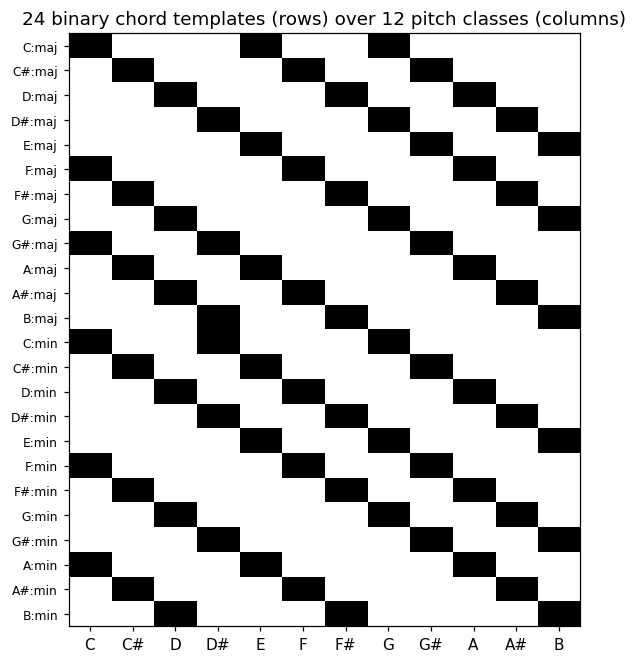

C:maj -> C E G    A:min -> ['C', 'E', 'A']


In [2]:
T = templates.build_templates()
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(T, cmap="Greys", aspect="auto")
ax.set_xticks(range(12)); ax.set_xticklabels(templates.PITCH_CLASSES)
ax.set_yticks(range(24)); ax.set_yticklabels(templates.CHORD_LABELS, fontsize=8)
ax.set_title("24 binary chord templates (rows) over 12 pitch classes (columns)")
plt.show()
print("C:maj ->", templates.PITCH_CLASSES[0], templates.PITCH_CLASSES[4], templates.PITCH_CLASSES[7],
      "   A:min ->", [templates.PITCH_CLASSES[i] for i in np.flatnonzero(T[templates.label_to_index('A:min')])])

## 5.2 Cosine similarity (Eq. 11)

$$ r_c(x[n]) = \frac{\langle x[n], t_c \rangle}{\lVert x[n] \rVert_2 \, \lVert t_c \rVert_2} \qquad (11) $$

The cosine of the angle between the observed chroma vector and template $c$: 1 if they point the same way, 0 if they share no pitch class. Because the chroma is already L2-normalised (Eq. 10) and $\lVert t_c \rVert_2 = \sqrt{3}$ for every template, the ranking is the same as a plain dot product — but the cosine form is what the paper writes, and it makes the numbers interpretable.

similarity matrix (24 templates × frames): (24, 173)  value range 0.155 … 0.801


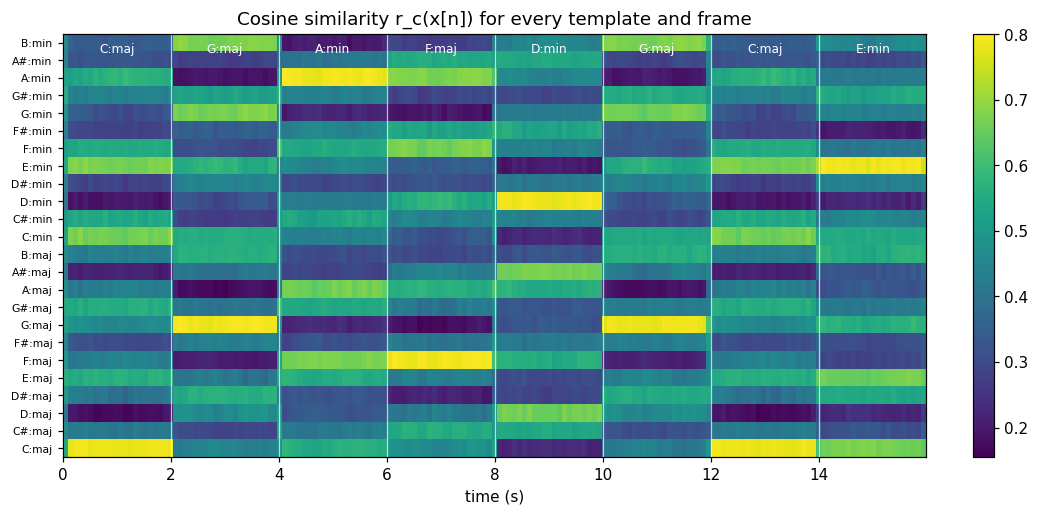

In [3]:
sr = features.SR
y, gt_intervals, gt_labels = synth.render_progression(synth.DEMO_PROGRESSION, 2.0, sr, timbre="piano")
chroma, times = features.cqt_chroma(y, sr)
sim = templates.cosine_similarity(chroma)
print("similarity matrix (24 templates × frames):", sim.shape, " value range", sim.min().round(3), "…", sim.max().round(3))

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(sim, aspect="auto", origin="lower", extent=[times[0], times[-1], -0.5, 23.5], cmap="viridis")
ax.set_yticks(range(24)); ax.set_yticklabels(templates.CHORD_LABELS, fontsize=7)
plots.overlay_segments(ax, gt_intervals, gt_labels, y=23, color="w")
ax.set(xlabel="time (s)", title="Cosine similarity r_c(x[n]) for every template and frame")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.show()

Each true chord produces a bright row, but notice the *secondary* bright rows: chords that share two notes with the truth (C:maj vs. A:min and E:min share two pitch classes each) score ≈ 2/3 of the maximum. Those are the chords template matching confuses.

## 5.3 Decode: take the argmax in every frame

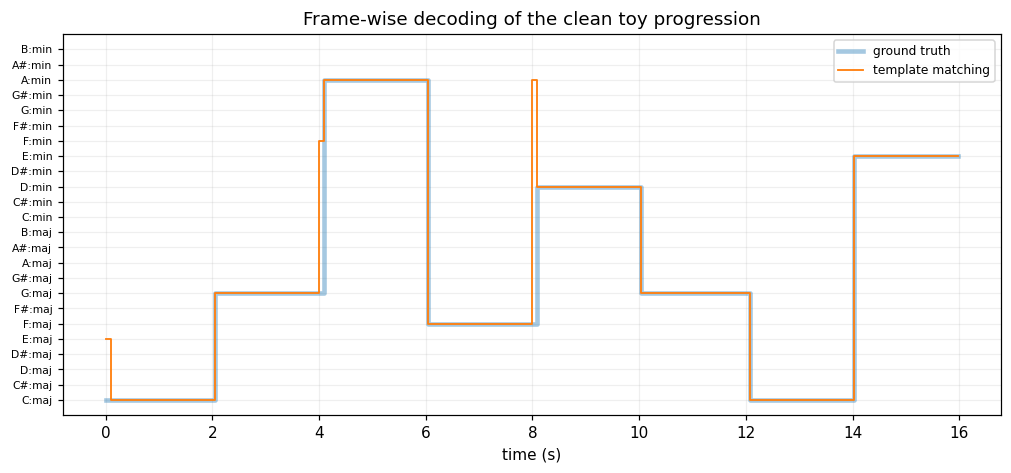

{'TP': 170, 'FP': 3, 'FN': 3, 'P': 0.9827, 'R': 0.9827, 'F1': 0.9827, 'n_frames': 173}


In [4]:
states_t, _ = templates.template_decode(chroma)
truth = evaluate.labels_to_frames(gt_intervals, gt_labels, times)

fig, ax = plt.subplots(figsize=(11, 4.5))
plots.plot_states(times, truth, states_t, labels=["ground truth", "template matching"], ax=ax, title="Frame-wise decoding of the clean toy progression")
plt.show()
metrics_clean = evaluate.frame_prf(states_t, truth)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics_clean.items()})

## 5.4 Precision, recall and F1 the way the paper counts them (Eqs. 19–20)

$$ P = \frac{TP}{TP + FP}, \qquad R = \frac{TP}{TP + FN}, \qquad F_1 = 2\,\frac{P \cdot R}{P + R} $$

with the paper's frame-wise bookkeeping: a *wrong* chord is both a false positive and a false negative, and a chord predicted during silence (`N`) is a false positive only. `evaluate.frame_prf` implements exactly this; notebook 8 compares it with the community-standard `mir_eval` scores.

On clean, isolated piano chords the template matcher is almost perfect. Now the same progression with drums and a melody line:

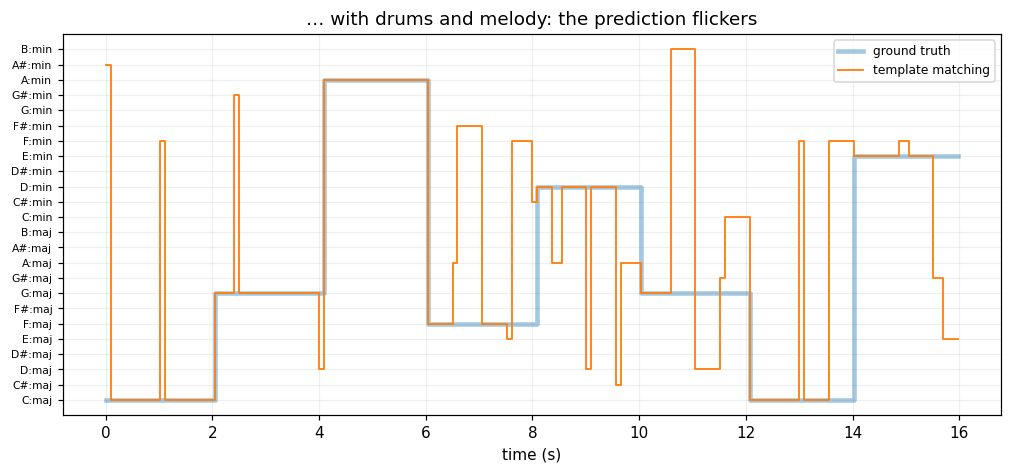

,TP,FP,FN,P,R,F1
clean,170.0,3.0,3.0,0.9827,0.9827,0.9827
drums + melody,119.0,54.0,54.0,0.6879,0.6879,0.6879


In [5]:
y_band = synth.add_melody(synth.add_drums(y, sr, level=1.0), gt_intervals, gt_labels, sr)
chroma_b, _ = features.cqt_chroma(y_band, sr)
states_b, sim_b = templates.template_decode(chroma_b)

fig, ax = plt.subplots(figsize=(11, 4.5))
plots.plot_states(times, truth, states_b, labels=["ground truth", "template matching"], ax=ax, title="… with drums and melody: the prediction flickers")
plt.show()
metrics_band = evaluate.frame_prf(states_b, truth)
pd.DataFrame({"clean": metrics_clean, "drums + melody": metrics_band}).T[["TP", "FP", "FN", "P", "R", "F1"]].round(4)

The failures are *isolated frames*: a drum hit or a melody note makes one frame look like another chord, the argmax jumps, and the next frame jumps back. Every jump is a false positive **and** a false negative in the paper's bookkeeping, which is why the template method's precision is the first thing the paper's HMM improves (§IV-A).

## 5.5 Which errors, exactly?

A confusion matrix over the 24 states shows *which* chords get confused — usually neighbours on the circle of fifths or the relative major/minor.

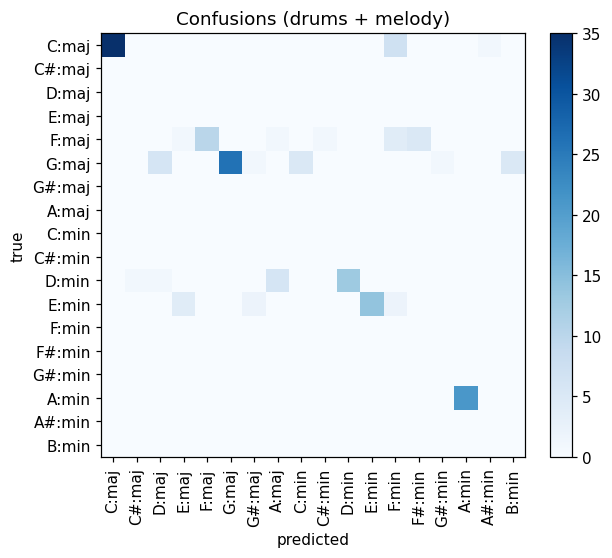

In [6]:
conf = np.zeros((24, 24), dtype=int)
for t_true, t_pred in zip(truth, states_b):
    if t_true >= 0:
        conf[t_true, t_pred] += 1
used = np.flatnonzero(conf.sum(axis=1) + conf.sum(axis=0))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf[np.ix_(used, used)], cmap="Blues")
ax.set_xticks(range(len(used))); ax.set_xticklabels([templates.CHORD_LABELS[i] for i in used], rotation=90)
ax.set_yticks(range(len(used))); ax.set_yticklabels([templates.CHORD_LABELS[i] for i in used])
ax.set(xlabel="predicted", ylabel="true", title="Confusions (drums + melody)")
plt.colorbar(im, ax=ax, fraction=0.046); plt.show()

## Exercises

1. Replace the binary templates by *harmonic* templates that also put weight (say 0.3) on the fifth's overtone positions. Does the confusion between a chord and its relative minor decrease? (`templates.template_decode(chroma, templates=my_T)`.)
2. Compute the average of the similarity matrix over time for `y_band`. Which wrong chord has the highest *average* similarity, and why?
3. Try `timbre="organ"` (sustained notes) instead of `"piano"`. Does the flicker change? What does that tell you about note decay?